# 📦 Notebook 01 — Thu thập & Chuẩn bị Dữ liệu

**Mục tiêu:**
- Khám phá (EDA) các dataset bình luận tiếng Việt có sẵn
- Chuẩn hóa schema thống nhất cho toàn bộ dữ liệu
- Gộp nhiều nguồn thành 1 dataset duy nhất
- (Tùy chọn) Crawl thêm dữ liệu từ Shopee

**Đầu ra:** `datas/processed/merged_sentiment.csv`

---
**Nguồn dữ liệu:**
| File | Nguồn | Kích thước |
|------|-------|------------|
| `khngxuninh__shopee_and_tiki_reviews...csv` | Shopee + Tiki | ~831 KB |
| `dduongdev__shopee_vietnamese.../shopee_reviews_dataset.jsonl` | Shopee | ~2.3 MB |
| `dduongdev__shopee_vietnamese.../aug_unaccented_reviews.jsonl` | Shopee (augmented) | ~518 KB |
| `tiki_sentiment/data - data.csv` | Tiki | ~2.1 MB |

## 1. Import thư viện

In [23]:
import pandas as pd
import numpy as np
import json
import os
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
from tqdm import tqdm

warnings.filterwarnings('ignore')

# Định nghĩa đường dẫn gốc
ROOT_DIR = Path('..').resolve()
DATA_DIR = ROOT_DIR / 'datas'
SENTIMENT_DIR = DATA_DIR / 'sentiment_dataset'
PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'✅ ROOT_DIR: {ROOT_DIR}')
print(f'✅ SENTIMENT_DIR: {SENTIMENT_DIR}')
print(f'✅ PROCESSED_DIR: {PROCESSED_DIR}')

✅ ROOT_DIR: F:\codingSpace\Asm\ecom_rcm_1
✅ SENTIMENT_DIR: F:\codingSpace\Asm\ecom_rcm_1\datas\sentiment_dataset
✅ PROCESSED_DIR: F:\codingSpace\Asm\ecom_rcm_1\datas\processed


## 2. Tải & Khám phá từng dataset

### 2.1 Dataset Khngxuninh (Shopee + Tiki CSV)

In [24]:
# --- Tải dataset CSV chính ---
csv_path = SENTIMENT_DIR / 'khngxuninh__shopee_and_tiki_reviews_vietnamese_version__final_train_dataset.csv'
df_khng = pd.read_csv(csv_path)

print(f'Shape: {df_khng.shape}')
print(f'Columns: {df_khng.columns.tolist()}')
print('\n--- Mẫu dữ liệu ---')
display(df_khng.head(3))

Shape: (2843, 3)
Columns: ['prod', 'com', 'rat']

--- Mẫu dữ liệu ---


,prod,com,rat
0,Áo Khoác Dây Kéo Dài Tay Nữ Tập Gym Thể Thao Y...,"k hiểu s cùng sp mà cái xịn cái tèo tèo, mua c...",4.0
1,Áo Khoác Dây Kéo Dài Tay Nữ Tập Gym Thể Thao Y...,Sản phẩm đóng gói tạm ổn \nChưa sử dụng chưa b...,4.0
2,Áo Khoác Dây Kéo Dài Tay Nữ Tập Gym Thể Thao Y...,Chất lượng sản phẩm:ok\nĐúng với mô tả:ok\nÁo ...,4.0


In [25]:
# Kiểm tra giá trị thiếu và phân phối nhãn
print('--- Giá trị thiếu ---')
print(df_khng.isnull().sum())
print('\n--- Phân phối nhãn ---')
print(df_khng.iloc[:, -1].value_counts())

--- Giá trị thiếu ---
prod    0
com     0
rat     0
dtype: int64

--- Phân phối nhãn ---
rat
5.0    1543
4.0     454
1.0     366
3.0     243
2.0     237
Name: count, dtype: int64


### 2.2 Dataset Dduongdev (Shopee JSONL)

In [26]:
# --- Tải dataset JSONL Shopee ---
def load_jsonl(filepath: str) -> pd.DataFrame:
    """Tải file JSONL thành DataFrame."""
    records = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)

dduong_dir = SENTIMENT_DIR / 'dduongdev__shopee_vietnamese_product_reviews_sentiment'

df_shopee_raw = load_jsonl(dduong_dir / 'shopee_reviews_dataset.jsonl')
df_shopee_aug = load_jsonl(dduong_dir / 'aug_unaccented_reviews.jsonl')

print(f'df_shopee_raw shape: {df_shopee_raw.shape}')
print(f'Columns: {df_shopee_raw.columns.tolist()}')
display(df_shopee_raw.head(3))

df_shopee_raw shape: (9599, 4)
Columns: ['id', 'review', 'rating', 'label']


,id,review,rating,label
0,74263765409,Hương vị:thom Chắc do bên giao hàng bị vỡ mấy...,3,negative
1,11104151002,Hương thơm:nhẹ nhàng Lợi ích:phục hồi cấp ẩm M...,5,positive
2,15888299382,Chất lượng sản phẩm:ok Đúng với mô tả:đúng Lầ...,5,positive


In [27]:
print(f'df_shopee_aug shape: {df_shopee_aug.shape}')
print(f'Columns: {df_shopee_aug.columns.tolist()}')
display(df_shopee_aug.head(3))

df_shopee_aug shape: (1348, 4)
Columns: ['id', 'review', 'rating', 'label']


,id,review,rating,label
0,59241444271,"Mui huong:Ngot nhe, thomm Phu hop voi loai da:...",4,positive
1,75292434640,Toi rat hai long voi dich vu cua nguoi ban va ...,5,positive
2,13364343551,Review nhe mot so dong sua con uong tang can t...,5,positive


### 2.3 Dataset Tiki Sentiment (CSV)

In [28]:
# --- Tải dataset Tiki ---
tiki_path = SENTIMENT_DIR / 'tiki_sentiment' / 'data - data.csv'
df_tiki = pd.read_csv(tiki_path, encoding='utf-8', on_bad_lines='skip')

print(f'df_tiki shape: {df_tiki.shape}')
print(f'Columns: {df_tiki.columns.tolist()}')
display(df_tiki.head(3))

df_tiki shape: (31460, 4)
Columns: ['comment', 'label', 'rate', 'Unnamed: 3']


,comment,label,rate,Unnamed: 3
0,Áo bao đẹp ạ!!,POS,5,NaN
1,Tuyệt vời !,POS,5,NaN
2,2day ao khong giong trong.,NEG,1,NaN


## 3. Chuẩn hóa Schema

In [29]:
def normalize_label(label) -> int:
    """
    Chuẩn hóa nhãn về 0 (tiêu cực) / 1 (tích cực).
    Hỗ trợ nhiều dạng: 0/1, 'positive'/'negative', 1-5 stars
    """
    if isinstance(label, (int, float)):
        val = int(label)
        if val in (0, 1):
            return val
        # Rating dạng sao 1-5: >=4 là tích cực
        if 1 <= val <= 5:
            return 1 if val >= 4 else 0
    if isinstance(label, str):
        label_lower = label.lower().strip()
        if label_lower in ('positive', 'pos', 'tích cực', '1', 'true'):
            return 1
        if label_lower in ('negative', 'neg', 'tiêu cực', '0', 'false'):
            return 0
    return -1  # Không xác định


def build_unified_df(text_series: pd.Series, label_series: pd.Series, source: str) -> pd.DataFrame:
    """
    Tạo DataFrame chuẩn với schema thống nhất:
    - review_text: nội dung bình luận
    - label: 0 (tiêu cực) / 1 (tích cực)
    - source: nguồn dữ liệu
    """
    df = pd.DataFrame({
        'review_text': text_series.astype(str).str.strip(),
        'label': label_series.apply(normalize_label),
        'source': source
    })
    # Loại bỏ nhãn không hợp lệ và text rỗng
    df = df[df['label'] != -1]
    df = df[df['review_text'].str.len() > 5]
    df = df.drop_duplicates(subset=['review_text'])
    return df.reset_index(drop=True)

print('✅ Hàm normalize_label và build_unified_df đã sẵn sàng')

✅ Hàm normalize_label và build_unified_df đã sẵn sàng


In [30]:
# ======================================================================
# Chuẩn hóa từng dataset — CẦN ĐIỀU CHỈNH tên cột sau khi chạy cell trên
# ======================================================================

# --- Dataset 1: Khngxuninh CSV ---
# Tự động phát hiện cột text và label
text_col_khng = df_khng.columns[0]  # Điều chỉnh nếu cần
label_col_khng = df_khng.columns[-1]
print(f'Dataset Khngxuninh → text: "{text_col_khng}", label: "{label_col_khng}"')

df1 = build_unified_df(df_khng[text_col_khng], df_khng[label_col_khng], source='khngxuninh_shopee_tiki')
print(f'df1 shape: {df1.shape}, Label dist: {df1["label"].value_counts().to_dict()}')

Dataset Khngxuninh → text: "prod", label: "rat"
df1 shape: (32, 3), Label dist: {1: 26, 0: 6}


In [31]:
# --- Dataset 2: Dduongdev Shopee raw ---
text_col_shopee = 'comment' if 'comment' in df_shopee_raw.columns else df_shopee_raw.columns[0]
label_col_shopee = 'label' if 'label' in df_shopee_raw.columns else df_shopee_raw.columns[-1]
print(f'Dataset Shopee Raw → text: "{text_col_shopee}", label: "{label_col_shopee}"')

df2 = build_unified_df(df_shopee_raw[text_col_shopee], df_shopee_raw[label_col_shopee], source='dduongdev_shopee_raw')
print(f'df2 shape: {df2.shape}, Label dist: {df2["label"].value_counts().to_dict()}')

Dataset Shopee Raw → text: "id", label: "label"
df2 shape: (9599, 3), Label dist: {0: 5965, 1: 3634}


In [32]:
# --- Dataset 3: Dduongdev augmented ---
text_col_aug = 'comment' if 'comment' in df_shopee_aug.columns else df_shopee_aug.columns[0]
label_col_aug = 'label' if 'label' in df_shopee_aug.columns else df_shopee_aug.columns[-1]
print(f'Dataset Augmented → text: "{text_col_aug}", label: "{label_col_aug}"')

df3 = build_unified_df(df_shopee_aug[text_col_aug], df_shopee_aug[label_col_aug], source='dduongdev_shopee_aug')
print(f'df3 shape: {df3.shape}, Label dist: {df3["label"].value_counts().to_dict()}')

Dataset Augmented → text: "id", label: "label"
df3 shape: (1348, 3), Label dist: {0: 677, 1: 671}


In [33]:
# --- Dataset 4: Tiki ---
text_col_tiki = 'comment' if 'comment' in df_tiki.columns else df_tiki.columns[0]
label_col_tiki = 'label' if 'label' in df_tiki.columns else df_tiki.columns[-1]
print(f'Dataset Tiki → text: "{text_col_tiki}", label: "{label_col_tiki}"')

df4 = build_unified_df(df_tiki[text_col_tiki], df_tiki[label_col_tiki], source='tiki_sentiment')
print(f'df4 shape: {df4.shape}, Label dist: {df4["label"].value_counts().to_dict()}')

Dataset Tiki → text: "comment", label: "label"
df4 shape: (22519, 3), Label dist: {1: 16193, 0: 6326}


## 4. Gộp toàn bộ dataset

In [34]:
# Gộp và shuffle
df_merged = pd.concat([df1, df2, df3, df4], ignore_index=True)
df_merged = df_merged.drop_duplicates(subset=['review_text']).reset_index(drop=True)
df_merged = df_merged.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print(f'✅ Dataset gộp: {df_merged.shape}')
print(f'Phân phối nhãn:\n{df_merged["label"].value_counts()}')
print(f'Nguồn dữ liệu:\n{df_merged["source"].value_counts()}')
display(df_merged.head(5))

✅ Dataset gộp: (32170, 3)
Phân phối nhãn:
label
1    19873
0    12297
Name: count, dtype: int64
Nguồn dữ liệu:
source
tiki_sentiment            22519
dduongdev_shopee_raw       9599
khngxuninh_shopee_tiki       32
dduongdev_shopee_aug         20
Name: count, dtype: int64


,review_text,label,source
0,Tốt Gói Hàng đẹp Shop phục vụ rất tốt.,1,tiki_sentiment
1,Mk nhận đk hàng rồi đẹp lắm cảm ơn shop nhé 😊.,1,tiki_sentiment
2,Bố t thích áo này lắm y.,1,tiki_sentiment
3,"Shop còn có quà cho khách nữa, rất hài lòng , ...",1,tiki_sentiment
4,76347487068,0,dduongdev_shopee_raw


## 5. Phân tích khám phá (EDA)

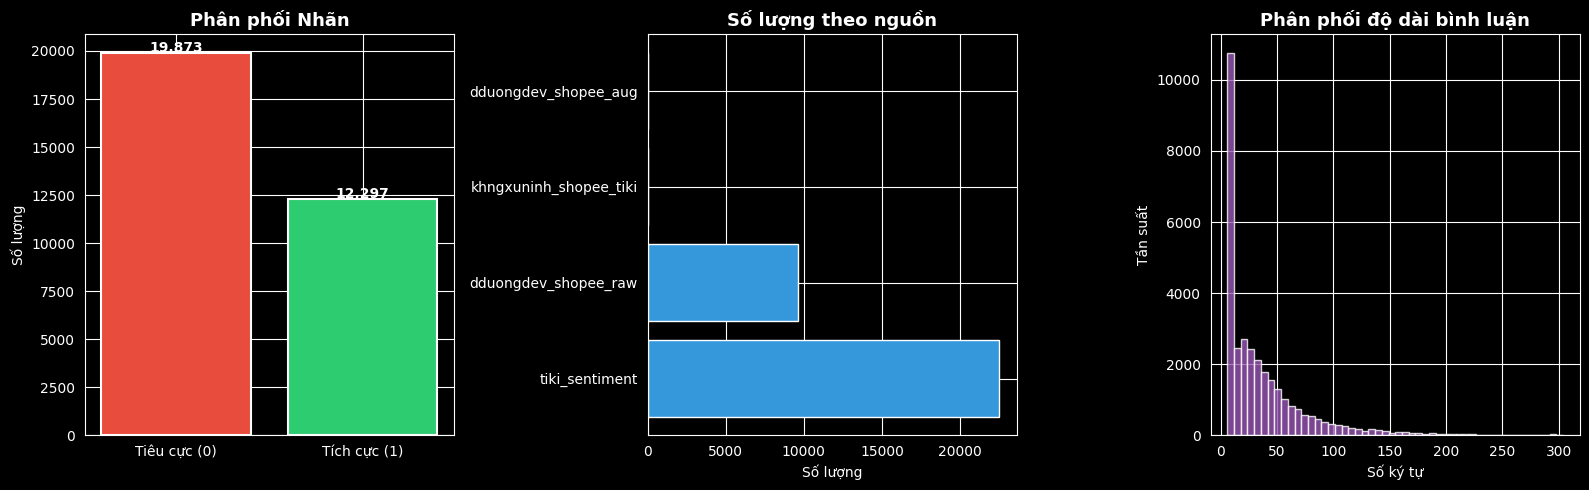

✅ Biểu đồ EDA đã lưu tại datas/processed/eda_overview.png


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Biểu đồ 1: Phân phối nhãn
label_counts = df_merged['label'].value_counts()
axes[0].bar(['Tiêu cực (0)', 'Tích cực (1)'], label_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Phân phối Nhãn', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Biểu đồ 2: Phân phối theo nguồn
source_counts = df_merged['source'].value_counts()
axes[1].barh(source_counts.index, source_counts.values, color='#3498db')
axes[1].set_title('Số lượng theo nguồn', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Số lượng')

# Biểu đồ 3: Phân phối độ dài bình luận
df_merged['text_length'] = df_merged['review_text'].str.len()
axes[2].hist(df_merged['text_length'].clip(upper=500), bins=50,
             color='#9b59b6', edgecolor='white', alpha=0.8)
axes[2].set_title('Phân phối độ dài bình luận', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Số ký tự')
axes[2].set_ylabel('Tần suất')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Biểu đồ EDA đã lưu tại datas/processed/eda_overview.png')

In [36]:
# Thống kê mô tả độ dài bình luận
print('--- Thống kê độ dài bình luận ---')
print(df_merged.groupby('label')['text_length'].describe().round(1))

--- Thống kê độ dài bình luận ---
         count  mean   std  min   25%   50%   75%    max
label                                                   
0      12297.0  28.4  31.1  6.0  11.0  11.0  36.0  304.0
1      19873.0  44.0  42.0  6.0  13.0  30.0  57.0  304.0


## 6. Lưu dataset đã gộp

In [37]:
# Lưu dataset gộp
output_path = PROCESSED_DIR / 'merged_sentiment.csv'
df_merged[['review_text', 'label', 'source']].to_csv(output_path, index=False, encoding='utf-8-sig')

print(f'✅ Đã lưu: {output_path}')
print(f'   Tổng số mẫu: {len(df_merged):,}')
print(f'   Tích cực: {(df_merged["label"]==1).sum():,} ({(df_merged["label"]==1).mean()*100:.1f}%)')
print(f'   Tiêu cực: {(df_merged["label"]==0).sum():,} ({(df_merged["label"]==0).mean()*100:.1f}%)')

✅ Đã lưu: F:\codingSpace\Asm\ecom_rcm_1\datas\processed\merged_sentiment.csv
   Tổng số mẫu: 32,170
   Tích cực: 19,873 (61.8%)
   Tiêu cực: 12,297 (38.2%)


## 7. Khám phá Recommend Dataset

In [38]:
REC_DIR = DATA_DIR / 'recommend_dataset'

# Load danh sách sản phẩm (Excel)
df_products = pd.read_excel(REC_DIR / 'data.xlsx')
print(f'Products shape: {df_products.shape}')
print(f'Columns: {df_products.columns.tolist()}')
display(df_products.head(3))

Products shape: (3060, 4)
Columns: ['item_id', 'shop_id', 'shop_location', 'name']


,item_id,shop_id,shop_location,name
0,6685849255,65589552,TP. Hồ Chí Minh,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...
1,1236186398,1657913,Hà Nội,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ..."
2,9764742653,453347243,TP. Hồ Chí Minh,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...


In [39]:
# Load mô tả sản phẩm Shopee (JSON)
with open(REC_DIR / 'shopee_product_desc.json', 'r', encoding='utf-8') as f:
    shopee_desc = json.load(f)

# Chuyển thành DataFrame nếu là list
if isinstance(shopee_desc, list):
    df_shopee_desc = pd.DataFrame(shopee_desc)
elif isinstance(shopee_desc, dict):
    df_shopee_desc = pd.DataFrame.from_dict(shopee_desc, orient='index')

print(f'Shopee desc shape: {df_shopee_desc.shape}')
print(f'Columns: {df_shopee_desc.columns.tolist()[:10]}')
display(df_shopee_desc.head(3))

Shopee desc shape: (13114, 2)
Columns: ['url', 'desc']


,url,desc
0,https://shopee.vn/Snack-hương-bò-thơm-cay-sườn...,🍒🍒🍒🍒Ngon nhé mọi người tha hồ cho bạn tận hươn...
1,https://shopee.vn/Gạo-lứt-đen-hữu-cơ-100-TÔM-V...,GẠO LỨT ĐEN (GẠO LỨT TÍM THAN) - TÔM VÀNG\n\n...
2,https://shopee.vn/Thanh-Gạo-Lứt-Granola-Mix-Ro...,💟💟💟 THANH GẠO LỨT CHÀ BÔNG MIX HẠT DINH DƯỠNG ...


In [40]:
# Khám phá dataset bổ sung từ repo mẫu (product-recommendation-system)
SAMPLE_REC_DIR = ROOT_DIR / 'samples' / 'product-recommendation-system' / 'datasets' / 'products_dataset'
product_files = sorted(SAMPLE_REC_DIR.glob('*.csv'))
print(f'📦 Tổng số file sản phẩm: {len(product_files)}')

if product_files:
    sample_file = product_files[0]
    df_sample = pd.read_csv(sample_file)
    print(f'File mẫu: {sample_file.name} -> {df_sample.shape}')
    display(df_sample.head(3))
else:
    print('⚠️ Không tìm thấy dataset sản phẩm trong repo mẫu')

📦 Tổng số file sản phẩm: 62
File mẫu: shopee_products_bàn.csv -> (300, 7)


,id,name,price,solds,image,rating,location
0,1,Bàn làm việc BUN - không kèm ghế (full phụ kiệ...,236.210,"Đã bán 155,3k",https://down-vn.img.susercontent.com/file/dc62...,4.8,TP. Hồ Chí Minh
1,2,Bàn ăn Bắc Âu nhà đơn giản hiện đại căn hộ nhỏ...,259.000,Đã bán 664,https://down-vn.img.susercontent.com/file/vn-1...,4.9,Hà Nội
2,3,Bàn gấp chân sắt bệt GB chắc chắn nhiều kích t...,328.000,Đã bán 259,https://down-vn.img.susercontent.com/file/ec83...,4.7,TP. Hồ Chí Minh


In [41]:
# Lưu summary để sử dụng ở Notebook 04
print('✅ Phase 1 hoàn thành!')
print('\n📁 Đầu ra:')
print(f'  - datas/processed/merged_sentiment.csv ({len(df_merged):,} bình luận)')
print(f'  - datas/processed/eda_overview.png')

✅ Phase 1 hoàn thành!

📁 Đầu ra:
  - datas/processed/merged_sentiment.csv (32,170 bình luận)
  - datas/processed/eda_overview.png


## 8. Kiểm thử đầu ra & trực quan hóa dữ liệu đã gộp

Cell bổ sung này dùng để kiểm tra nhanh chất lượng dataset sau khi gộp. Mục tiêu là đảm bảo file đầu ra có đúng schema, nhãn hợp lệ, ít giá trị thiếu và có thể dùng tiếp cho Notebook 02.


In [42]:
# Kiểm thử schema và chất lượng dữ liệu sau khi gộp
merged_path = PROCESSED_DIR / 'merged_sentiment.csv'
assert merged_path.exists(), f'Không tìm thấy file đầu ra: {merged_path}'

if 'df_merged' not in globals():
    df_merged = pd.read_csv(merged_path)

required_cols = {'review_text', 'label', 'source'}
missing_cols = required_cols - set(df_merged.columns)
assert not missing_cols, f'Thiếu cột bắt buộc: {missing_cols}'

qa_summary = pd.DataFrame({
    'metric': [
        'total_rows', 'duplicate_reviews', 'empty_review_text',
        'invalid_labels', 'num_sources', 'avg_review_length'
    ],
    'value': [
        len(df_merged),
        int(df_merged.duplicated(subset=['review_text']).sum()),
        int(df_merged['review_text'].isna().sum() + (df_merged['review_text'].astype(str).str.strip() == '').sum()),
        int((~df_merged['label'].isin([0, 1])).sum()),
        int(df_merged['source'].nunique()),
        round(df_merged['review_text'].astype(str).str.split().str.len().mean(), 2),
    ]
})

print('✅ Kiểm thử schema và dữ liệu hoàn tất')
display(qa_summary)
display(df_merged.groupby(['source', 'label']).size().reset_index(name='count').sort_values(['source', 'label']))


✅ Kiểm thử schema và dữ liệu hoàn tất


,metric,value
0,total_rows,32170.00
1,duplicate_reviews,0.00
2,empty_review_text,0.00
3,invalid_labels,0.00
4,num_sources,4.00
5,avg_review_length,8.22


,source,label,count
0,dduongdev_shopee_aug,1,20
1,dduongdev_shopee_raw,0,5965
2,dduongdev_shopee_raw,1,3634
3,khngxuninh_shopee_tiki,0,6
4,khngxuninh_shopee_tiki,1,26
5,tiki_sentiment,0,6326
6,tiki_sentiment,1,16193


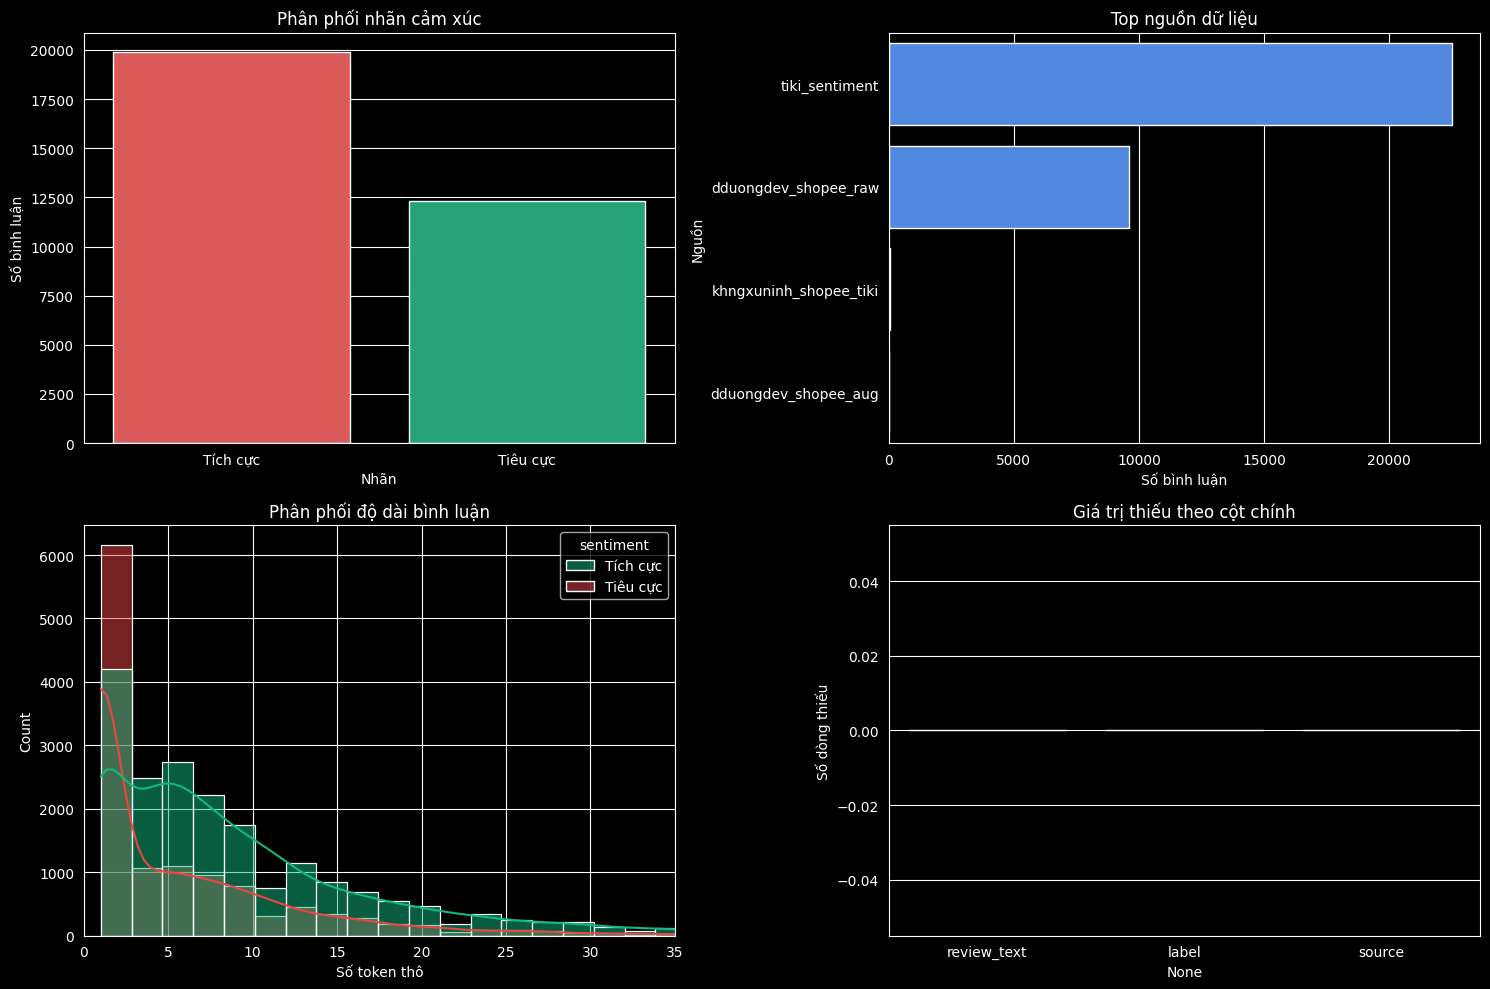

✅ Đã lưu biểu đồ kiểm thử dữ liệu: datas/processed/merged_data_quality.png


In [43]:
# Visualize phân phối dữ liệu sau khi gộp
plot_df = df_merged.copy()
plot_df['review_length'] = plot_df['review_text'].astype(str).str.split().str.len()
plot_df['sentiment'] = plot_df['label'].map({0: 'Tiêu cực', 1: 'Tích cực'})

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=plot_df, x='sentiment', palette=['#ef4444', '#10b981'], ax=axes[0, 0])
axes[0, 0].set_title('Phân phối nhãn cảm xúc')
axes[0, 0].set_xlabel('Nhãn')
axes[0, 0].set_ylabel('Số bình luận')

source_counts = plot_df['source'].value_counts().head(10)
sns.barplot(x=source_counts.values, y=source_counts.index, ax=axes[0, 1], color='#3b82f6')
axes[0, 1].set_title('Top nguồn dữ liệu')
axes[0, 1].set_xlabel('Số bình luận')
axes[0, 1].set_ylabel('Nguồn')

sns.histplot(data=plot_df, x='review_length', hue='sentiment', bins=40, kde=True,
             palette={'Tiêu cực': '#ef4444', 'Tích cực': '#10b981'}, ax=axes[1, 0])
axes[1, 0].set_title('Phân phối độ dài bình luận')
axes[1, 0].set_xlabel('Số token thô')
axes[1, 0].set_xlim(0, plot_df['review_length'].quantile(0.98))

missing_counts = plot_df[['review_text', 'label', 'source']].isna().sum()
sns.barplot(x=missing_counts.index, y=missing_counts.values, ax=axes[1, 1], color='#f59e0b')
axes[1, 1].set_title('Giá trị thiếu theo cột chính')
axes[1, 1].set_ylabel('Số dòng thiếu')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'merged_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ kiểm thử dữ liệu: datas/processed/merged_data_quality.png')


In [44]:
# Hiển thị mẫu dữ liệu đại diện theo từng nhãn để kiểm tra thủ công
# Không dùng groupby.apply trực tiếp để tránh khác biệt hành vi giữa các phiên bản pandas.
sample_parts = []
for label_value, group_df in df_merged.groupby('label'):
    cols = [col for col in ['review_text', 'label', 'source'] if col in group_df.columns]
    sample_parts.append(
        group_df[cols].sample(min(5, len(group_df)), random_state=42)
    )

sample_review = pd.concat(sample_parts, ignore_index=True)

display(sample_review)
print('Gợi ý dùng cho báo cáo: chèn bảng mẫu này để minh họa dữ liệu đầu vào sau chuẩn hóa schema.')


,review_text,label,source
0,12061141112,0,dduongdev_shopee_raw
1,52431331336,0,dduongdev_shopee_raw
2,Phần áo cắt bị nham nhở 😔.,0,tiki_sentiment
3,"Chỉ có lưu ý nhỏ là hình in bị ra màu, nhưng k...",0,tiki_sentiment
4,Giao k đúng màu..,0,tiki_sentiment
5,Chất lượng quá ổn so vs giá tiền.,1,tiki_sentiment
6,Giao hàng siêu siêu thần tốc luôn.,1,tiki_sentiment
7,"Áo đẹp y hình... cám ơn shop, shop vô cùng dễ ...",1,tiki_sentiment
8,Chất lượng sản phẩm tuyệt vời bản quốc tế mới ...,1,tiki_sentiment
9,80830974112,1,dduongdev_shopee_raw


Gợi ý dùng cho báo cáo: chèn bảng mẫu này để minh họa dữ liệu đầu vào sau chuẩn hóa schema.
